# Part 1 - Neural Network Fundamentals and Training Behavior Analysis

## Installing Required Libraries

In [2]:
!pip install pandas numpy


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib seaborn scikit-learn


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install tensorflow

     -------------------------------------- 350.6/350.6 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 437.9/437.9 kB 1.7 MB/s eta 0:00:00
     ---------------------------------------- 60.3/60.3 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 2.9/2.9 MB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 4.9/4.9 MB 2.8 MB/s eta 0:00:00
     ---------------------------------------- 26.4/26.4 MB 1.7 MB/s eta 0:00:00
  Using cached gast-0.7.0-py3-none-any.whl (22 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl (7.7 kB)
     -------------------------------------- 210.7/210.7 kB 2.2 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 2.2 MB/s eta 0:00:00
  Using cached wheel-0

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Arif Ahmed Vastari\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\clang\\native\\libclang.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
     -------------------------------------- 135.8/135.8 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 26.4/26.4 MB 3.6 MB/s eta 0:00:00
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached grpcio-1.80.0-cp310-cp310-win_amd64.whl (4.9 MB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl (437 kB)
  Using cached wrapt-2.1.2-cp310-cp310-win_amd64.whl (60 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
     ---------------------------------------- 57.5/57.5 kB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB 1.3 MB/s eta 0:00:00
     -------------------------------------- 210.7/210.7 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 2.4 MB/s eta 0:00:00
     -------------------------------------- 310.7/310.7 kB 3.9 MB/s eta 0:00:00
     -------------------------------------- 327.9/327.9 kB 


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing required libraries


In [5]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
# Loading the dataset

df = pd.read_csv("dataset/customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## Dataset Understanding

In [7]:
# Checking dataset shape

print("Number of rows and columns:", df.shape)

# Checking column names
print("\nColumns in the dataset:\n")
print(df.columns)

# Checking data types
print("\nData types:\n")
print(df.dtypes)

Number of rows and columns: (2000, 17)

Columns in the dataset:

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data types:

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent

In [8]:
# Checking missing values

print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [9]:
# Statistical summary of numerical columns

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Target Variable Distribution

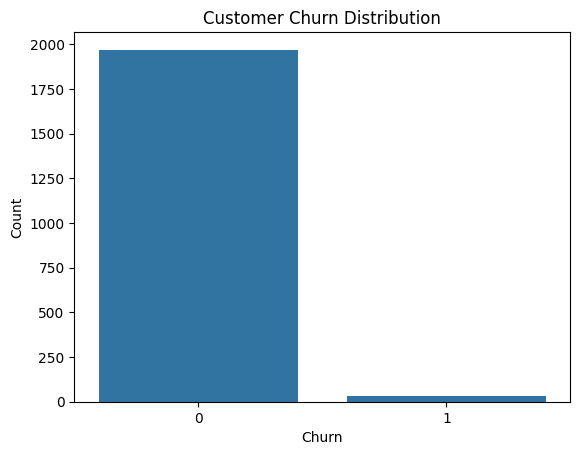

In [10]:
# Visualizing churn distribution

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains customer information and the target column is churn. 
The graph shows the number of customers who stayed and customers who left the company. 
This helps in understanding whether the dataset is balanced or imbalanced.